In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity

from sklearn.cluster import KMeans
from sklearn.cluster import MeanShift
from sklearn import preprocessing

%config InlineBackend.figure_format='retina'
plt.rc('text', usetex=True)

Let's look at the latest database of Gamma Ray Bursts. Some relevant physical questions you might want to tackle include:

- Does the distribution contain different sub-populations? How many?
- What's the threshold between the classes?
- If you try two clustering methods, do you get more or less the same?
- How do methods respond to outliers?
- What variable(s) shows the multi-modality more evidently?
- Are all GRBs equally likely to be observed? 



In [2]:
data = np.loadtxt('Summary_table.txt', usecols=[6,9])

In [3]:
np.shape(data)

(9158, 2)

In [4]:
t90 = np.log(data[:,0])
flux = np.log(data[:,1])

mask = np.isfinite(t90) & np.isfinite(flux)

x = t90[mask]
y = flux[mask]


/var/folders/_h/ldjx52094bd50nf5x0f85ybr0000gn/T/ipykernel_71948/38745705.py:1: RuntimeWarning: invalid value encountered in log
  t90 = np.log(data[:,0])
/var/folders/_h/ldjx52094bd50nf5x0f85ybr0000gn/T/ipykernel_71948/38745705.py:2: RuntimeWarning: divide by zero encountered in log
  flux = np.log(data[:,1])
/var/folders/_h/ldjx52094bd50nf5x0f85ybr0000gn/T/ipykernel_71948/38745705.py:2: RuntimeWarning: invalid value encountered in log
  flux = np.log(data[:,1])


Text(0, 0.5, 'log(flux)')

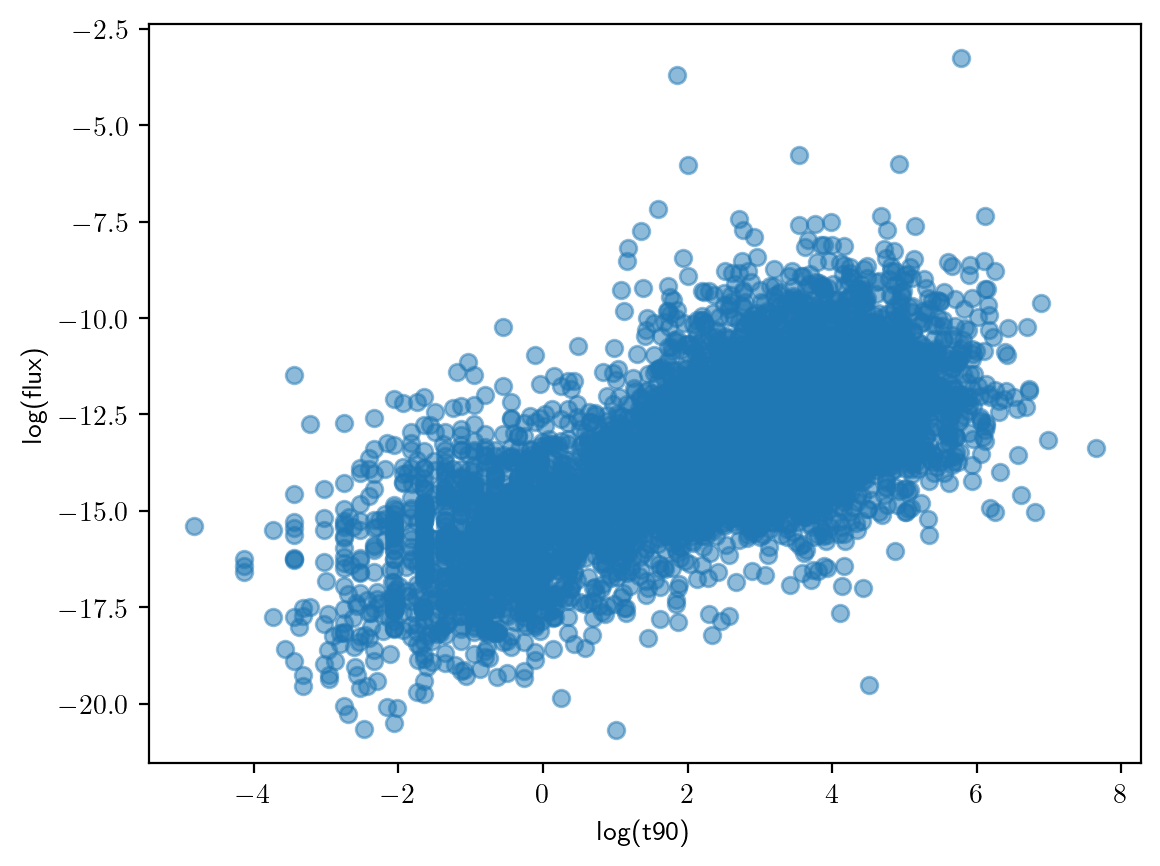

In [5]:
plt.plot(x,y, linewidth = 0, marker = 'o', alpha = 0.5)
plt.xlabel('log(t90)')
plt.ylabel('log(flux)')

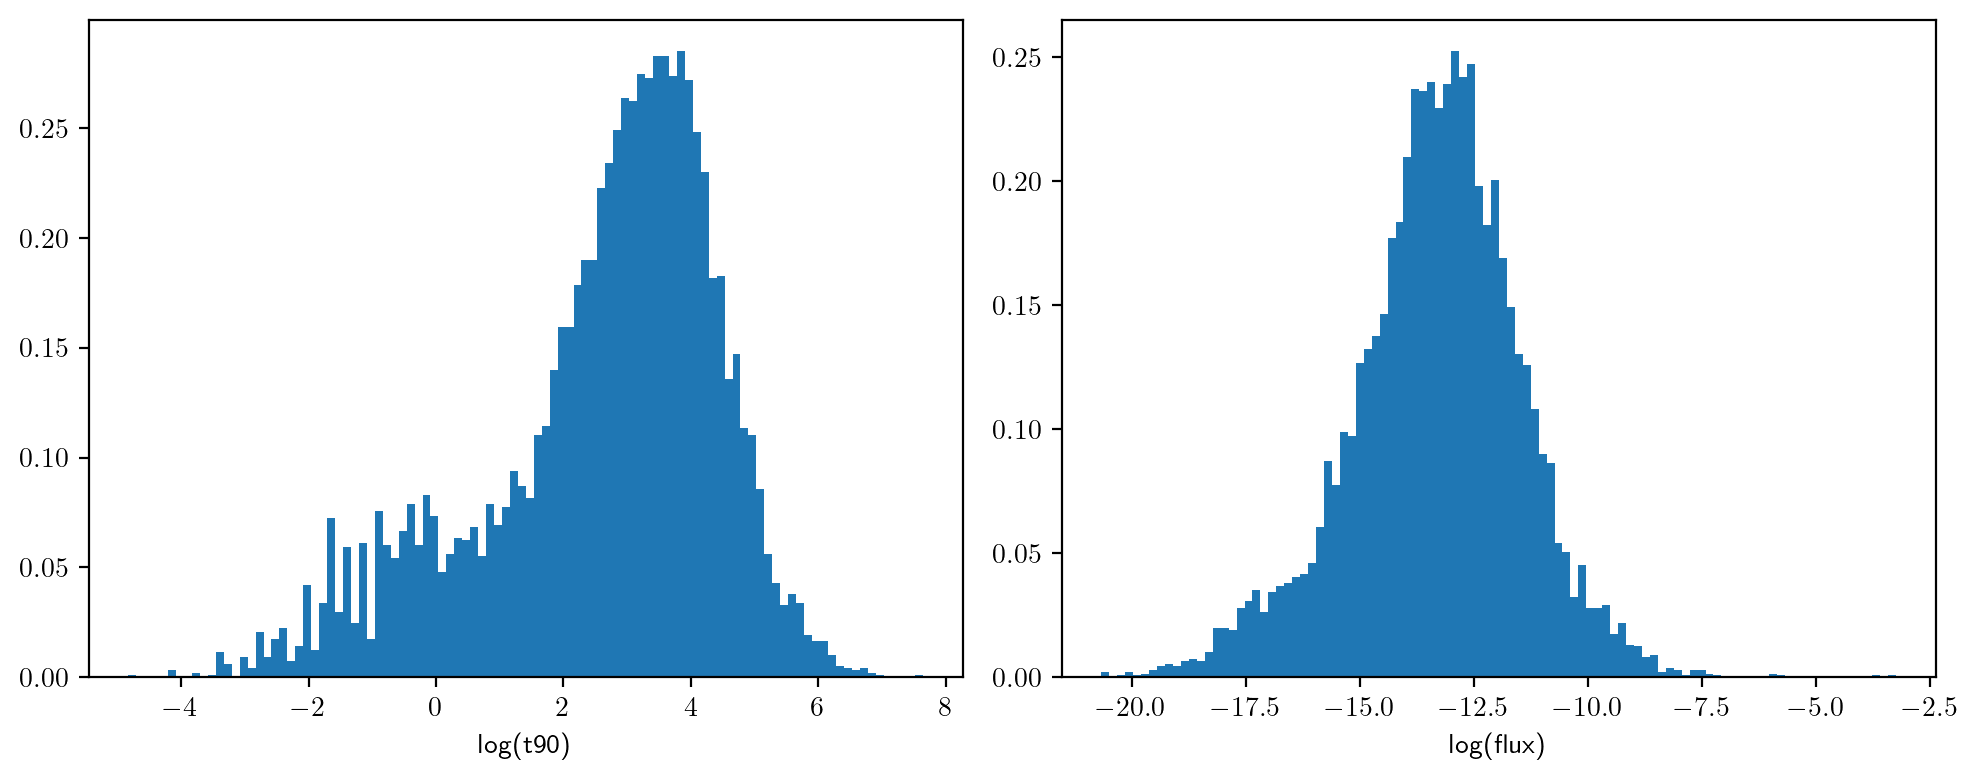

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(x, bins=100, density=True)
ax[0].set_xlabel('log(t90)')

ax[1].hist(y, bins=100, density=True)
ax[1].set_xlabel('log(flux)')

plt.tight_layout()

In [7]:
aic = np.zeros(10)

for n in range(1,11):

    model = GaussianMixture(n)
    fit = model.fit(x[:,np.newaxis])
    aic[n-1] = fit.aic(x[:,np.newaxis])

best = np.arange(1,11)[np.argmin(aic)]
print(best)

2


In [8]:
# K-MEANS CLUSTERING

km_data = x[:,np.newaxis]

clf = KMeans(n_clusters=2, n_init='auto')
clf.fit(km_data)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(km_data) #labels for each point

print(centers)

[[ 3.49435931]
 [-0.08006365]]


In [9]:
if centers[0]>centers[1]:
    centers=centers[::-1] # Reverse array
    labels = np.array(~np.array(labels,dtype='bool'),dtype='int') # Swap 0 <--> 1

print(centers)

edge = np.mean([max(x[labels==0]), min(x[labels==1])])
print(np.exp(edge))

[[-0.08006365]
 [ 3.49435931]]
5.511994194481702


In [17]:
# MEAN-SHIFT CLUSTERING

scaler = preprocessing.StandardScaler()
bandwidth = .4
#bandwidth = estimate_bandwidth(X_reduced) # this takes a long time...beware
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True, cluster_all=False)
ms.fit(scaler.fit_transform(km_data))

labels_unique = np.unique(ms.labels_)
n_clusters = len(labels_unique[labels_unique >= 0])
print(labels_unique)
print("number of estimated clusters :", n_clusters)

[-1  0  1]
number of estimated clusters : 2


In [18]:
cluster_centers = scaler.inverse_transform(ms.cluster_centers_)

print(cluster_centers)

[[3.49652311]
 [0.31802864]]


In [19]:
xgrid = np.linspace(x.min(), x.max(), 2000)
grid_labels = ms.predict(scaler.transform(xgrid[:,np.newaxis]))
changes = np.where(np.diff(grid_labels) != 0)[0]
boundaries = xgrid[changes]

print("Cluster boundary:")
print(np.exp(boundaries.ravel()))

Cluster boundary:
[6.73244462]


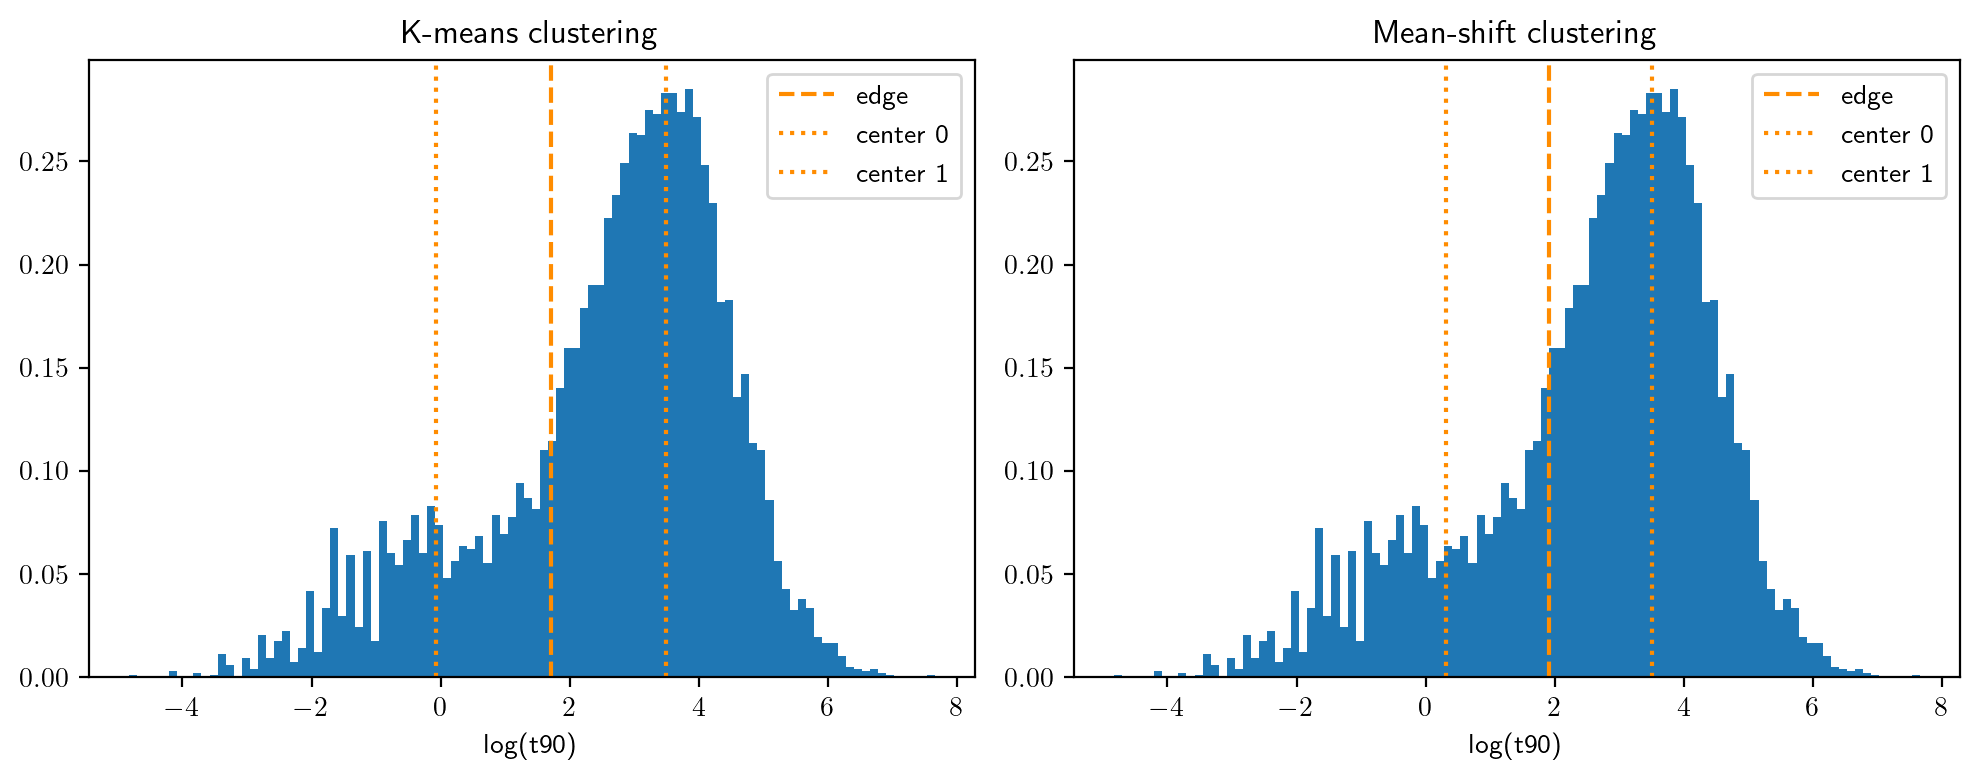

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].set_title('K-means clustering')
ax[0].hist(x, bins = 100, density=True)
ax[0].axvline(edge, c = 'darkorange', ls = '--', label = 'edge')

for i, cc in enumerate(centers):
    ax[0].axvline(cc, c = 'darkorange', ls = ':', label = f'center {i}')

ax[0].legend()
ax[0].set_xlabel('log(t90)')

ax[1].set_title('Mean-shift clustering')
ax[1].hist(x, bins = 100, density=True)
ax[1].axvline(boundaries[0], c = 'darkorange', ls = '--', label = 'edge')

for i, cc in enumerate(cluster_centers):
    ax[1].axvline(cc, c = 'darkorange', ls = ':', label = f'center {i}')

ax[1].legend()
ax[1].set_xlabel('log(t90)')

plt.tight_layout()